In [1]:
from skimage import io

# Load the tif file
image_stack = io.imread('images/xAM_data_processing_Sudarsh/mT89_re2_DMEM_2025-04-18@20-27-57.tif')

image_stack = image_stack[:, 300:700, :]

In [2]:
image_stack.shape

(1073, 400, 641)

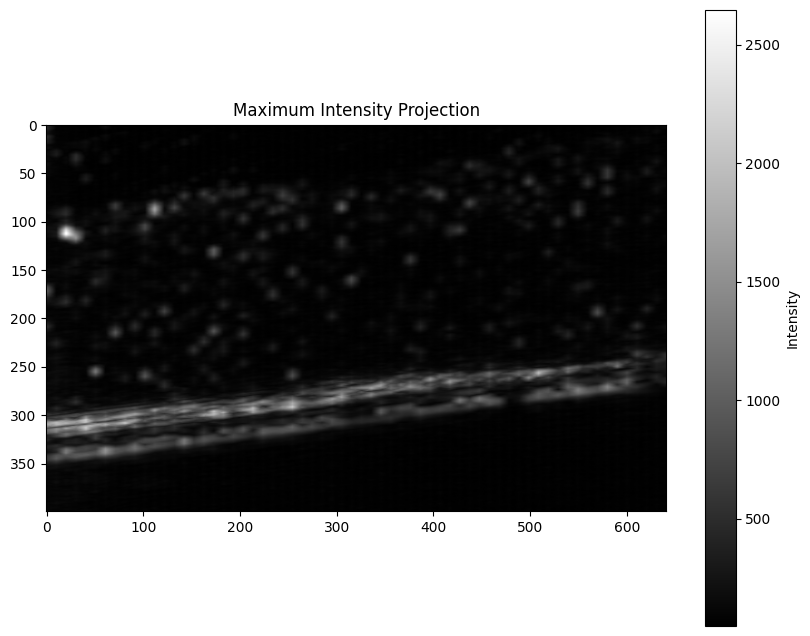

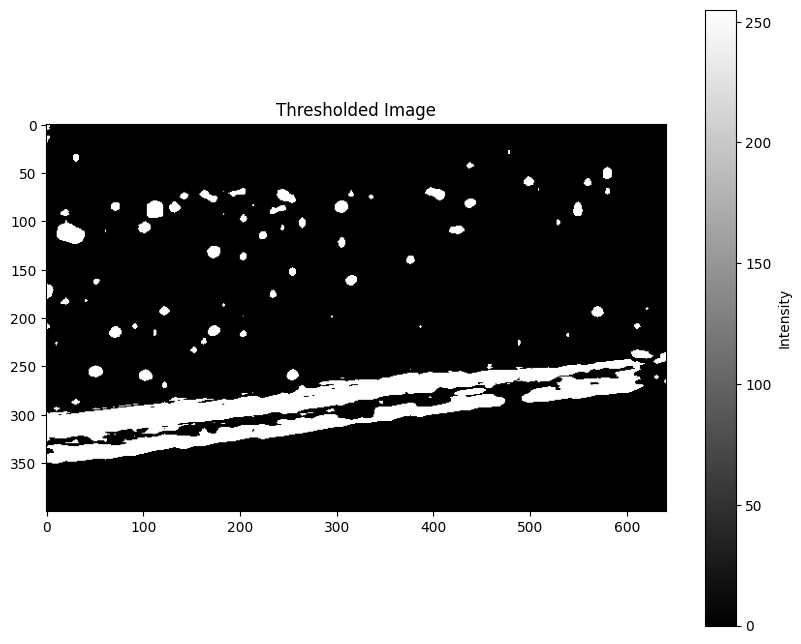

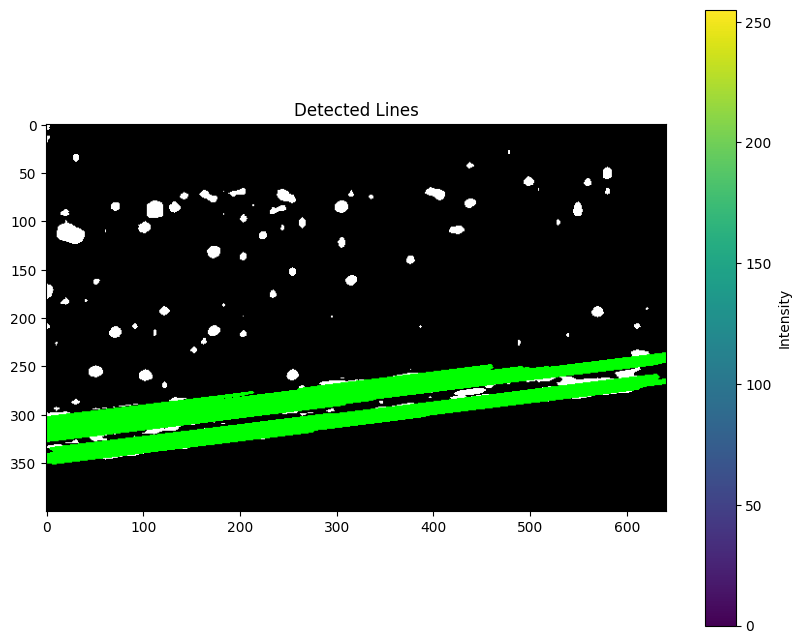

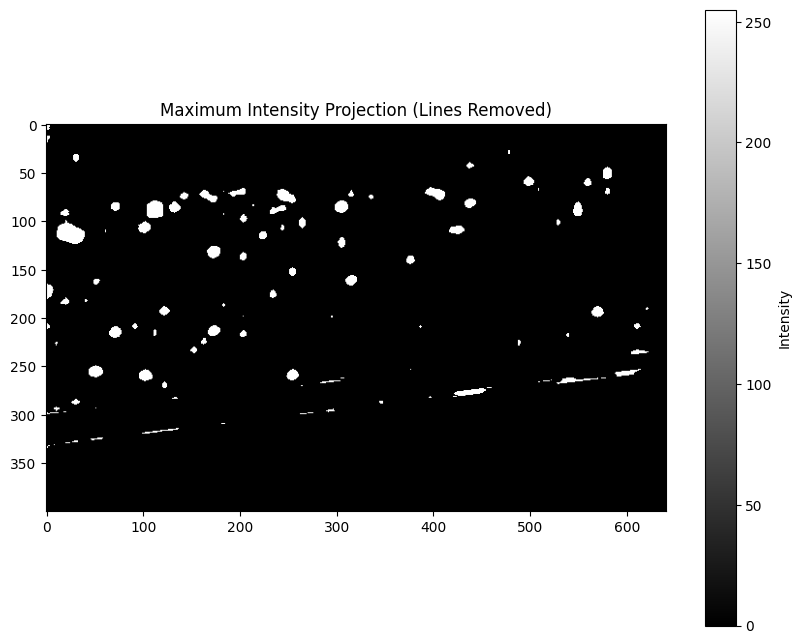

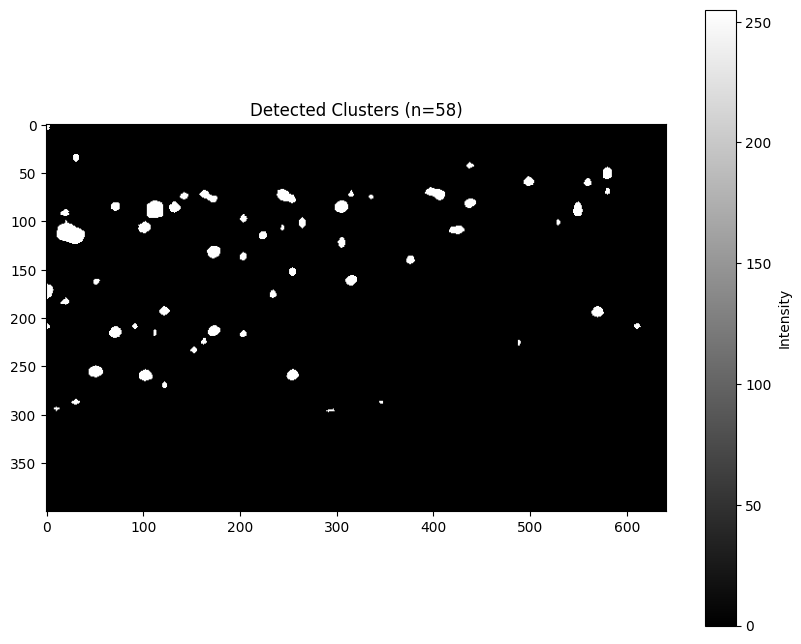

Total number of clusters detected: 58
Cluster 1:
  Area: 24 pixels
  Bounding box: x=0, y=0, width=5, height=7
  Centroid: (1.4, 2.4)
  Eccentricity: 0.855
Cluster 4:
  Area: 40 pixels
  Bounding box: x=28, y=31, width=6, height=8
  Centroid: (30.5, 34.2)
  Eccentricity: 0.646
Cluster 5:
  Area: 33 pixels
  Bounding box: x=434, y=39, width=8, height=7
  Centroid: (437.3, 42.3)
  Eccentricity: 0.567
Cluster 6:
  Area: 97 pixels
  Bounding box: x=575, y=44, width=9, height=13
  Centroid: (578.9, 50.4)
  Eccentricity: 0.486
Cluster 7:
  Area: 78 pixels
  Bounding box: x=493, y=54, width=11, height=10
  Centroid: (497.9, 58.9)
  Eccentricity: 0.527
Cluster 8:
  Area: 48 pixels
  Bounding box: x=555, y=56, width=8, height=8
  Centroid: (558.7, 59.8)
  Eccentricity: 0.406
Cluster 9:
  Area: 178 pixels
  Bounding box: x=391, y=65, width=21, height=14
  Centroid: (402.0, 71.2)
  Eccentricity: 0.876
Cluster 11:
  Area: 187 pixels
  Bounding box: x=238, y=67, width=20, height=15
  Centroid: (247

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

max_image = image_stack.max(axis = 0)
# Recompute max image after cropping
max_image = image_stack.max(axis=0)


# Plot max image
plt.figure(figsize=(10,8))
plt.imshow(max_image, cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Maximum Intensity Projection')
plt.show()

# Create binary thresholded image
threshold = np.percentile(max_image, 90)  # Use same threshold as before
thresholded_image = (max_image > threshold).astype(np.uint8) * 255

# Display the thresholded image
plt.figure(figsize=(10,8))
plt.imshow(thresholded_image, cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Thresholded Image')
plt.show()

binary_image = (thresholded_image).astype(np.uint8) * 255

# Apply Hough transform
lines = cv2.HoughLinesP(binary_image, 
                        rho=1,
                        theta=np.pi/180,
                        threshold=40,
                        minLineLength=150,
                        maxLineGap=40)

# Create a copy of max_image for visualization
line_image = cv2.cvtColor(thresholded_image.astype(np.uint8), cv2.COLOR_GRAY2BGR)

# Draw detected lines
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display the result
plt.figure(figsize=(10,8))
plt.imshow(line_image)
plt.title('Detected Lines')
plt.colorbar(label='Intensity')
plt.show()

# Create a mask for the lines
line_mask = np.zeros_like(max_image)
for line in lines:
    x1, y1, x2, y2 = line[0]
    # Draw thicker lines (width=5) on the mask
    cv2.line(line_mask, (x1, y1), (x2, y2), 1, 5)

thresholded_image[line_mask > 0] = 0

plt.figure(figsize=(10,8))
plt.imshow(thresholded_image, cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Maximum Intensity Projection (Lines Removed)')
plt.show()

# Find connected components (clusters) in the thresholded image
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresholded_image, connectivity=8)

# Calculate eccentricity for each component
eccentricities = []
for i in range(1, num_labels):
    # Get component mask
    component = (labels == i).astype(np.uint8)
    # Find contours
    contours, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        # Fit ellipse to contour
        if len(contours[0]) >= 5:  # Need at least 5 points to fit ellipse
            ellipse = cv2.fitEllipse(contours[0])
            major_axis = max(ellipse[1])
            minor_axis = min(ellipse[1])
            eccentricity = np.sqrt(1 - (minor_axis/major_axis)**2)
        else:
            eccentricity = 0
    else:
        eccentricity = 0
    eccentricities.append(eccentricity)

# Filter clusters based on size and eccentricity
min_cluster_size = 10  # Reduced size threshold
max_eccentricity = 0.95  # Filter out very elongated shapes
valid_clusters = np.logical_and(
    stats[1:, cv2.CC_STAT_AREA] > min_cluster_size,
    np.array(eccentricities) < max_eccentricity
)

# Create a visualization of the clusters
cluster_image = np.zeros_like(thresholded_image)
colors = np.random.randint(50, 255, size=(len(stats), 3), dtype=np.uint8)
colors[0] = [0, 0, 0]  # Background is black

for i in range(1, num_labels):
    if valid_clusters[i-1]:
        cluster_image[labels == i] = 255

# Display the clusters
plt.figure(figsize=(10,8))
plt.imshow(cluster_image, cmap='gray')
plt.colorbar(label='Intensity')
plt.title(f'Detected Clusters (n={np.sum(valid_clusters)})')
plt.show()

# Print cluster statistics
print(f"Total number of clusters detected: {np.sum(valid_clusters)}")
for i in range(1, num_labels):
    if valid_clusters[i-1]:
        area = stats[i, cv2.CC_STAT_AREA]
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        print(f"Cluster {i}:")
        print(f"  Area: {area} pixels")
        print(f"  Bounding box: x={x}, y={y}, width={w}, height={h}")
        print(f"  Centroid: ({centroids[i][0]:.1f}, {centroids[i][1]:.1f})")
        print(f"  Eccentricity: {eccentricities[i-1]:.3f}")








In [4]:
import numpy as np
from scipy.signal import savgol_filter

# Count number of valid clusters
n_valid = np.sum(valid_clusters)

# Initialize array to store all cluster intensities
cell_intensities = np.zeros((n_valid, len(image_stack)))

# Counter for valid clusters
cluster_idx = 0

# For each valid cluster, calculate its mean intensity over time
for i in range(1, num_labels):
    if valid_clusters[i-1]:
        # Create a mask for this cluster
        cluster_mask = (labels == i)
        
        # Calculate mean intensity over time for this cluster
        for t in range(len(image_stack)):
            mean_intensity = np.mean(image_stack[t][cluster_mask])
            cell_intensities[cluster_idx, t] = mean_intensity
            
        # Calculate baseline using a very wide window moving average
        window_size = len(image_stack) // 4  # Use 1/4 of signal length
        if window_size % 2 == 0:  # Make window size odd
            window_size += 1
        baseline = savgol_filter(cell_intensities[cluster_idx], window_size, 3)
        
        # Subtract baseline
        cell_intensities[cluster_idx] -= baseline
        
        cluster_idx += 1

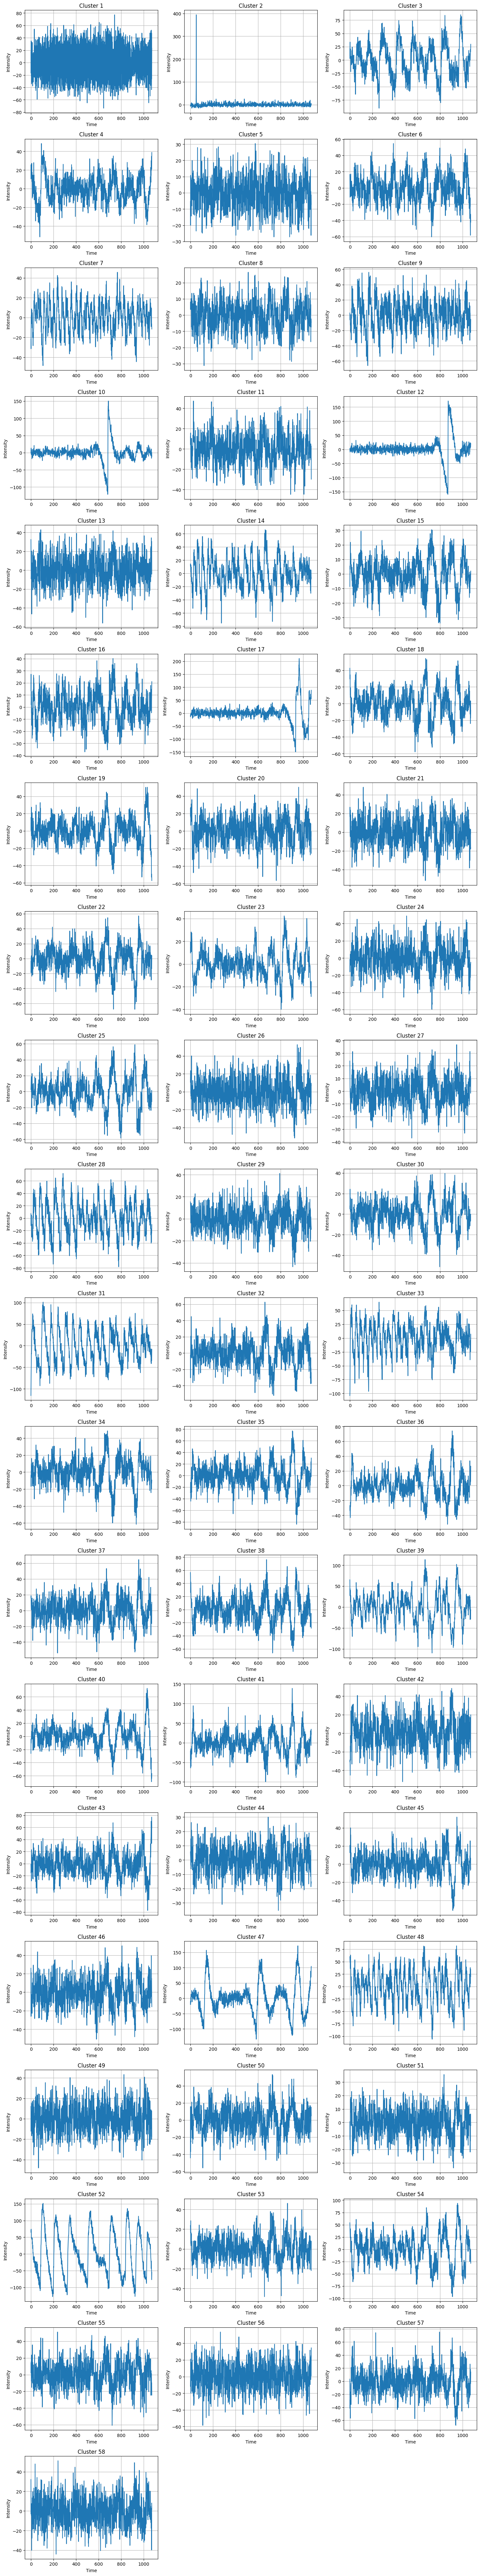

In [5]:
# Create a figure with subplots for each cluster
n_rows = int(np.ceil(n_valid / 3))  # 3 columns
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()

# Plot each cluster's intensity over time
for i in range(n_valid):
    axes[i].plot(cell_intensities[i], label=f'Cluster {i+1}')
    axes[i].set_title(f'Cluster {i+1}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Intensity')
    axes[i].grid(True)

# Hide empty subplots
for i in range(n_valid, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

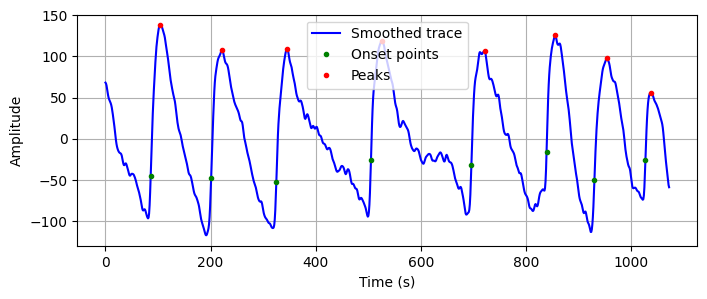

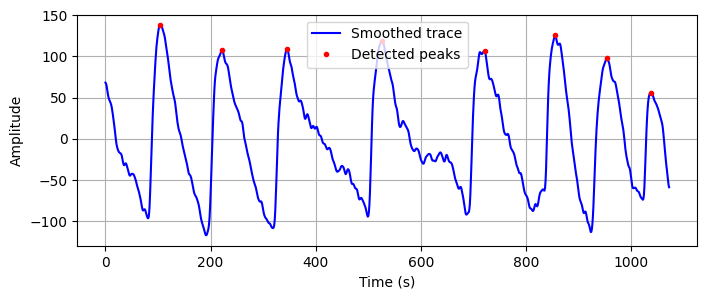

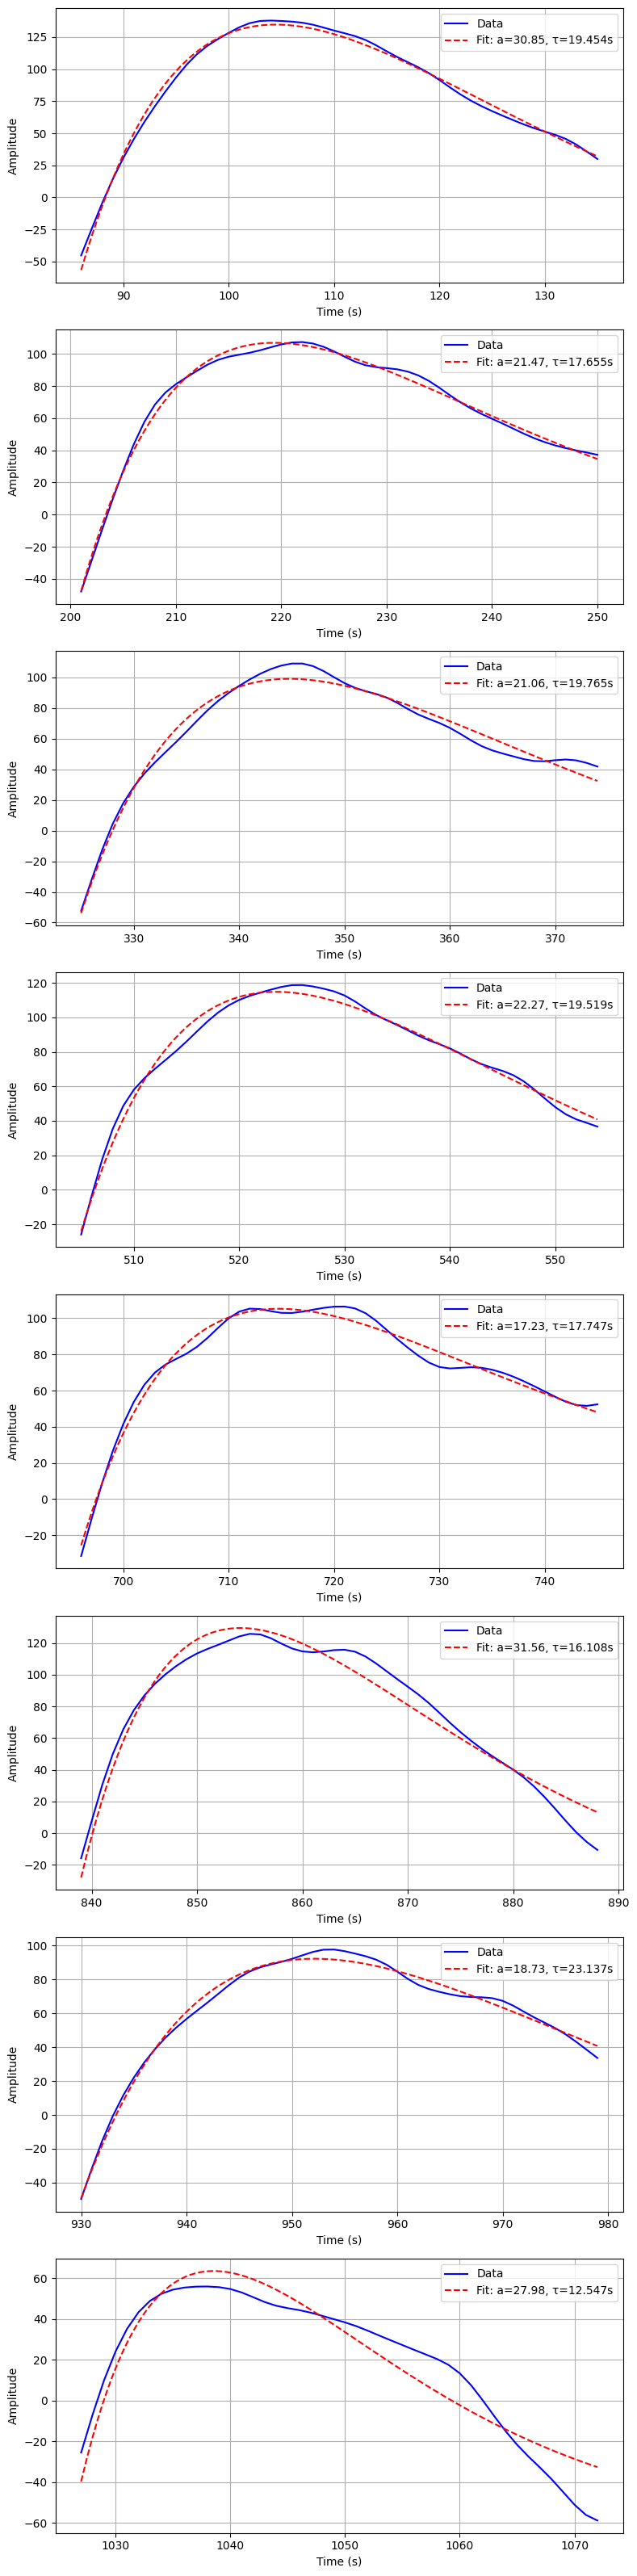

8
[array([ 30.85019916,  19.45424117, -86.0148634 ,  85.        ]), array([ 21.46701509,  17.65463339, -32.56036968, 201.66839347]), array([ 21.0580694 ,  19.76506244, -53.98029015, 324.9900732 ]), array([ 22.27226716,  19.51928689, -45.14766115, 504.        ]), array([ 17.23370899,  17.74680796,  -7.30715058, 697.        ]), array([ 31.5584816 ,  16.10783797, -57.59559148, 838.        ]), array([ 18.725988  ,  23.13671291, -67.13262368, 929.        ]), array([  27.9832888 ,   12.54650106,  -65.56095213, 1026.        ])]


In [65]:
"""
ca_spike_analysis.py

Detect calcium spikes in a single-cell fluorescence trace and fit a decaying
kernel of the form `a · x · exp(-x/τ)` around each spike.

Main entry‑point
----------------
analyze_trace(trace,
              sampling_rate=1.0,
              smooth_sigma=2,
              prominence=0.3,
              amplitude_thresh=0.1,
              r2_thresh=0.6,
              plot=True)

Returns
-------
fits : list[dict]
    Each dict has keys ``peak_idx``, ``a``, ``tau``, and ``r2``.
fig  : matplotlib.figure.Figure | None
    Only when ``plot=True``.
"""
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

__all__ = ["analyze_trace"]

def _kernel(x: np.ndarray, a: float, tau: float, c: float, d:float) -> np.ndarray:
    """a · (x-d) · exp(-(x-d)/τ) + c, with ``x ≥ d`` assumed.
    
    Parameters
    ----------
    x : time points
    a : amplitude scaling factor
    tau : decay time constant
    c : baseline offset
    d : time offset/delay
    """
    return a * (x - d) * np.exp(-(x - d) / tau) + c


def analyze_trace(
    trace: np.ndarray,
    *,
    sampling_rate: float = 1.0,
    smooth_sigma: float = 2.0,
    prominence: float = 10,
    amplitude_thresh: float = 0.1,
    fit_thresh: float = 0.1,
    plot: bool = True,
):
    """Detect spikes, fit decay kernels, and optionally plot.

    Parameters
    ----------
    trace
        1‑D fluorescence time‑series.
    sampling_rate
        Samples per second.
    smooth_sigma
        Gaussian σ (in *samples*) for pre‑smoothing.
    prominence
        Minimum peak prominence for ``scipy.signal.find_peaks``.
    amplitude_thresh
        Absolute threshold (after smoothing) below which peaks are ignored.
    fit_thresh
        Minimum R² value for accepting a fit.
    plot
        If *True*, return a Matplotlib figure showing the *smoothed* trace and
        the fitted kernels (raw trace is **not** plotted).
    """
    # --- Pre‑processing ----------------------------------------------------
    trace = np.asarray(trace, dtype=float)
    if trace.ndim != 1:
        raise ValueError("trace must be 1‑D, got shape {}".format(trace.shape))

    t = np.arange(trace.size) / sampling_rate
    smooth = ndi.gaussian_filter1d(trace, sigma=smooth_sigma)

    # --- Peak detection ----------------------------------------------------
    peaks, _ = find_peaks(
        smooth,
        prominence=prominence,
        distance=5,
        height=amplitude_thresh,
    )
    
    # Find onset points by looking for local minima before peaks
    inverted_smooth = -smooth
    onset_points = []
    for peak in peaks:
        # Look back up to 30 points before each peak
        search_start = max(0, peak - 30)
        window = smooth[search_start:peak+1]
        # Find the point of maximum slope (derivative)
        derivatives = np.diff(window)
        # Get index of maximum derivative relative to window
        max_deriv_idx = np.argmax(derivatives)
        # Convert back to full trace index
        onset_idx = search_start + max_deriv_idx
        onset_points.append(onset_idx)
    
    onset_points = np.array(onset_points)
    
    if plot:
        # Plot onset points for verification
        plt.figure(figsize=(8, 3))
        plt.plot(t, smooth, 'b-', label='Smoothed trace')
        plt.plot(t[onset_points], smooth[onset_points], 'g.', label='Onset points')
        plt.plot(t[peaks], smooth[peaks], 'r.', label='Peaks')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Plot peaks on the smoothed trace
        plt.figure(figsize=(8, 3))
        plt.plot(t, smooth, 'b-', label='Smoothed trace')
        plt.plot(t[peaks], smooth[peaks], 'r.', label='Detected peaks')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Split trace into segments based on onset points and peaks
    segments = []
    segment_fits = []
    
    # Create segments from onset to next onset (or end)
    for i in range(len(onset_points)):
        start = onset_points[i]
        if i < len(onset_points)-1:
            end = min(onset_points[i+1], start + 50)  # Limit segment length
        else:
            end = min(len(smooth), start + 50)  # Limit final segment
            
        # Get segment data
        t_segment = t[start:end]
        y_segment = smooth[start:end]
        
        # Only fit if we have enough points
        if len(t_segment) < 10:
            continue
            
        try:
            # Initial parameter guesses
            peak_val = np.max(y_segment)
            baseline = np.min(y_segment)
            # Better initial guesses
            a0 = (peak_val - baseline) / (t_segment[1] - t_segment[0])  # Initial amplitude
            tau0 = (t_segment[-1] - t_segment[0]) / 3  # Initial time constant
            d0 = t_segment[0]  # Initial time offset
            
            p0 = [a0, tau0, baseline, d0]
            
            # Add bounds to prevent nonsensical fits
            bounds = ([0, 0.001, -np.inf, t_segment[0]-1],  # lower bounds
                     [np.inf, 1000, np.inf, t_segment[0]+1])  # upper bounds
            
            # Fit curve
            popt, pcov = curve_fit(_kernel,
                                 t_segment,
                                 y_segment,
                                 p0=p0,
                                 bounds=bounds,
                                 maxfev=2000)  # Increase max iterations
            
            # Calculate R-squared
            y_fit = _kernel(t_segment, *popt)
            residuals = y_segment - y_fit
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y_segment - np.mean(y_segment))**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            # Only keep fits above threshold and with physical tau values
            if r_squared >= fit_thresh and 0 < popt[1] < 1000:
                segments.append((t_segment, y_segment))
                segment_fits.append(popt)
            
        except RuntimeError as e:
            print(f"Could not fit segment {i}: {str(e)}")
            continue
    
    if plot:
        # Plot each segment with its fit
        fig, axes = plt.subplots(len(segments), 1, figsize=(8, 4*len(segments)))
        if len(segments) == 1:
            axes = [axes]
            
        for i, ((t_seg, y_seg), fit) in enumerate(zip(segments, segment_fits)):
            axes[i].plot(t_seg, y_seg, 'b-', label='Data')
            
            # Generate fitted curve
            t_fit = np.linspace(t_seg[0], t_seg[-1], 100)
            y_fit = _kernel(t_fit, *fit)
            
            axes[i].plot(t_fit, y_fit, 'r--', 
                        label=f'Fit: a={fit[0]:.2f}, τ={fit[1]:.3f}s')
            axes[i].set_xlabel('Time (s)')
            axes[i].set_ylabel('Amplitude')
            axes[i].legend()
            axes[i].grid(True)
            
        plt.tight_layout()
        plt.show()
    
    # Calculate statistics for a and tau
    a_values = [fit[0] for fit in segment_fits]
    tau_values = [fit[1] for fit in segment_fits]
    
    stats = {
        'a_mean': np.mean(a_values),
        'a_std': np.std(a_values),
        'tau_mean': np.mean(tau_values),
        'tau_std': np.std(tau_values)
    }
    
    return segment_fits, stats

fits, values = analyze_trace(cell_intensities[51], fit_thresh=0.8, plot = True)
print(len(fits))
print(fits)
# fig.show()


Spiking: 50, Non-spiking: 8
Original number of values: 50
Number of values after removing outliers: 48


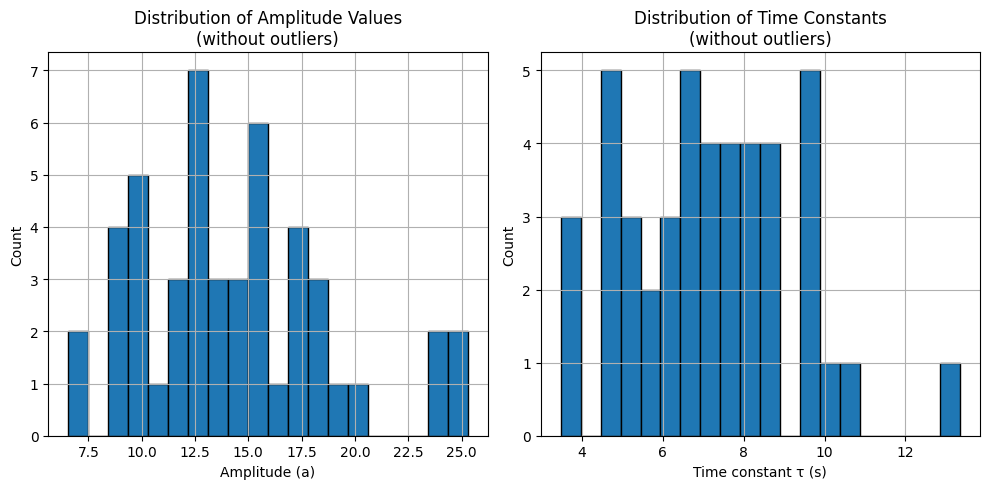

In [64]:
spiking = 0
non_spiking = 0

values_arr = []

for cell_intensity in cell_intensities:
    fits, values = analyze_trace(cell_intensity, fit_thresh=0.8, plot=False)
    if len(fits) > 2:
        values_arr.append(values)
        spiking += 1
    else:
        non_spiking += 1

print(f"Spiking: {spiking}, Non-spiking: {non_spiking}")

# Extract a and tau values from all cells
a_values = [v['a_mean'] for v in values_arr]
tau_values = [v['tau_mean'] for v in values_arr]

# Remove outliers using IQR method
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

a_values_clean = remove_outliers(a_values)
tau_values_clean = remove_outliers(tau_values)

print(f"Original number of values: {len(a_values)}")
print(f"Number of values after removing outliers: {len(a_values_clean)}")

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Create histograms
ax1.hist(a_values_clean, bins=20, edgecolor='black')
ax2.hist(tau_values_clean, bins=20, edgecolor='black')

# Add labels
ax1.set_xlabel('Amplitude (a)')
ax1.set_ylabel('Count')
ax2.set_xlabel('Time constant τ (s)')
ax2.set_ylabel('Count')

# Add titles
ax1.set_title('Distribution of Amplitude Values\n(without outliers)')
ax2.set_title('Distribution of Time Constants\n(without outliers)')

# Add grid
ax1.grid(True)
ax2.grid(True)

plt.tight_layout()
plt.show()
